In [1]:
# Import libries
import numpy as np
import pandas as pd
import os

current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


## aaSuite_germline_ss

In [12]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()
sample_mapping.head()


,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10
3,ECTRES-ECGI1-0001-TPX-A11-WGS-9HJ669,ECGI1,ECTRES-ECGI1-0001-TPX-A11,ECTRES-ECGI1-0001,EG_11
4,ECTRES-ECGI1-0001-TPX-A12-WGS-4SL389,ECGI1,ECTRES-ECGI1-0001-TPX-A12,ECTRES-ECGI1-0001,EG_12
5,ECTRES-ECGI1-0001-TPX-A13-WGS-3VZ640,ECGI1,ECTRES-ECGI1-0001-TPX-A13,ECTRES-ECGI1-0001,EG_13


# dna_fingerprint

In [2]:
# /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/dna_fingerprint/all
base_dir = '/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results'

dna_fingerprint_all_path = f'{base_dir}/dna_fingerprint/all/crosscheck_metrics'

dna_fingerprint_all = pd.read_csv(dna_fingerprint_all_path, sep='\t', skiprows=6)

dna_fingerprint_all.shape

(5929, 19)

In [16]:
# 1. Left Sample에 대한 정보 추가
df_mapped = dna_fingerprint_all.merge(
    sample_mapping, 
    left_on='LEFT_SAMPLE', 
    right_on='sample_barcode', 
    how='left'
)

# 컬럼명 구분 (left_ 접두사 추가)
df_mapped = df_mapped.rename(columns={
    'source_barcode': 'left_source_barcode',
    'sample_barcode': 'left_sample_barcode',
    'patient_barcode': 'left_patient_barcode',
    'sample_id': 'left_sample_id'
}).drop(columns=['aliquot_barcode']) # 중복 키 삭제

# 2. Right Sample에 대한 정보 추가
df_mapped = df_mapped.merge(
    sample_mapping, 
    left_on='RIGHT_SAMPLE', 
    right_on='sample_barcode', 
    how='left'
)

# 컬럼명 구분 (right_ 접두사 추가)
df_mapped = df_mapped.rename(columns={
    'source_barcode': 'right_source_barcode',
    'sample_barcode': 'right_sample_barcode',
    'patient_barcode': 'right_patient_barcode',
    'sample_id': 'right_sample_id'
}).drop(columns=['aliquot_barcode'])

# 결과 확인
df_mapped.head()

,LEFT_GROUP_VALUE,RIGHT_GROUP_VALUE,RESULT,DATA_TYPE,LOD_SCORE,LOD_SCORE_TUMOR_NORMAL,LOD_SCORE_NORMAL_TUMOR,LEFT_RUN_BARCODE,LEFT_LANE,LEFT_MOLECULAR_BARCODE_SEQUENCE,...,RIGHT_SAMPLE,RIGHT_FILE,left_source_barcode,left_sample_barcode,left_patient_barcode,left_sample_id,right_source_barcode,right_sample_barcode,right_patient_barcode,right_sample_id
0,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,EXPECTED_MATCH,FILE,4458.609856,-4233.073357,-4239.228432,2333VCLT4,6,NaN,...,ECTRES-ECGI1-0001-TPX-A07,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,ECGI1,ECTRES-ECGI1-0001-TPX-A07,ECTRES-ECGI1-0001,EG_7,ECGI1,ECTRES-ECGI1-0001-TPX-A07,ECTRES-ECGI1-0001,EG_7
1,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,2048.535588,-6689.839176,-6796.143079,2333VCLT4,6,NaN,...,ECTRES-ECGI1-0001-TPX-A09,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,ECGI1,ECTRES-ECGI1-0001-TPX-A07,ECTRES-ECGI1-0001,EG_7,ECGI1,ECTRES-ECGI1-0001-TPX-A09,ECTRES-ECGI1-0001,EG_9
2,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1788.190766,-3844.030653,-3845.995766,2333VCLT4,6,NaN,...,ECTRES-ECGI1-0001-TPX-A29,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,ECGI1,ECTRES-ECGI1-0001-TPX-A07,ECTRES-ECGI1-0001,EG_7,ECGI1,ECTRES-ECGI1-0001-TPX-A29,ECTRES-ECGI1-0001,EG_29
3,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,EXPECTED_MISMATCH,FILE,-3299.147930,-10600.825516,-10880.019123,2333VCLT4,6,NaN,...,ECTRES-H2170-0001-TPX-A12,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,ECGI1,ECTRES-ECGI1-0001-TPX-A07,ECTRES-ECGI1-0001,EG_7,H2170,ECTRES-H2170-0001-TPX-A12,ECTRES-H2170-0001,NCI_12
4,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,EXPECTED_MISMATCH,FILE,-18665.149937,-25271.613273,-10438.457996,2333VCLT4,6,NaN,...,ECTRES-EFM19-0001-TPX-A01,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,ECGI1,ECTRES-ECGI1-0001-TPX-A07,ECTRES-ECGI1-0001,EG_7,EFM19,ECTRES-EFM19-0001-TPX-A01,ECTRES-EFM19-0001,parental


In [17]:
dna_fingerprint_all['RESULT'].value_counts()

RESULT
EXPECTED_MISMATCH    3628
UNEXPECTED_MATCH     2218
EXPECTED_MATCH         83
Name: count, dtype: int64

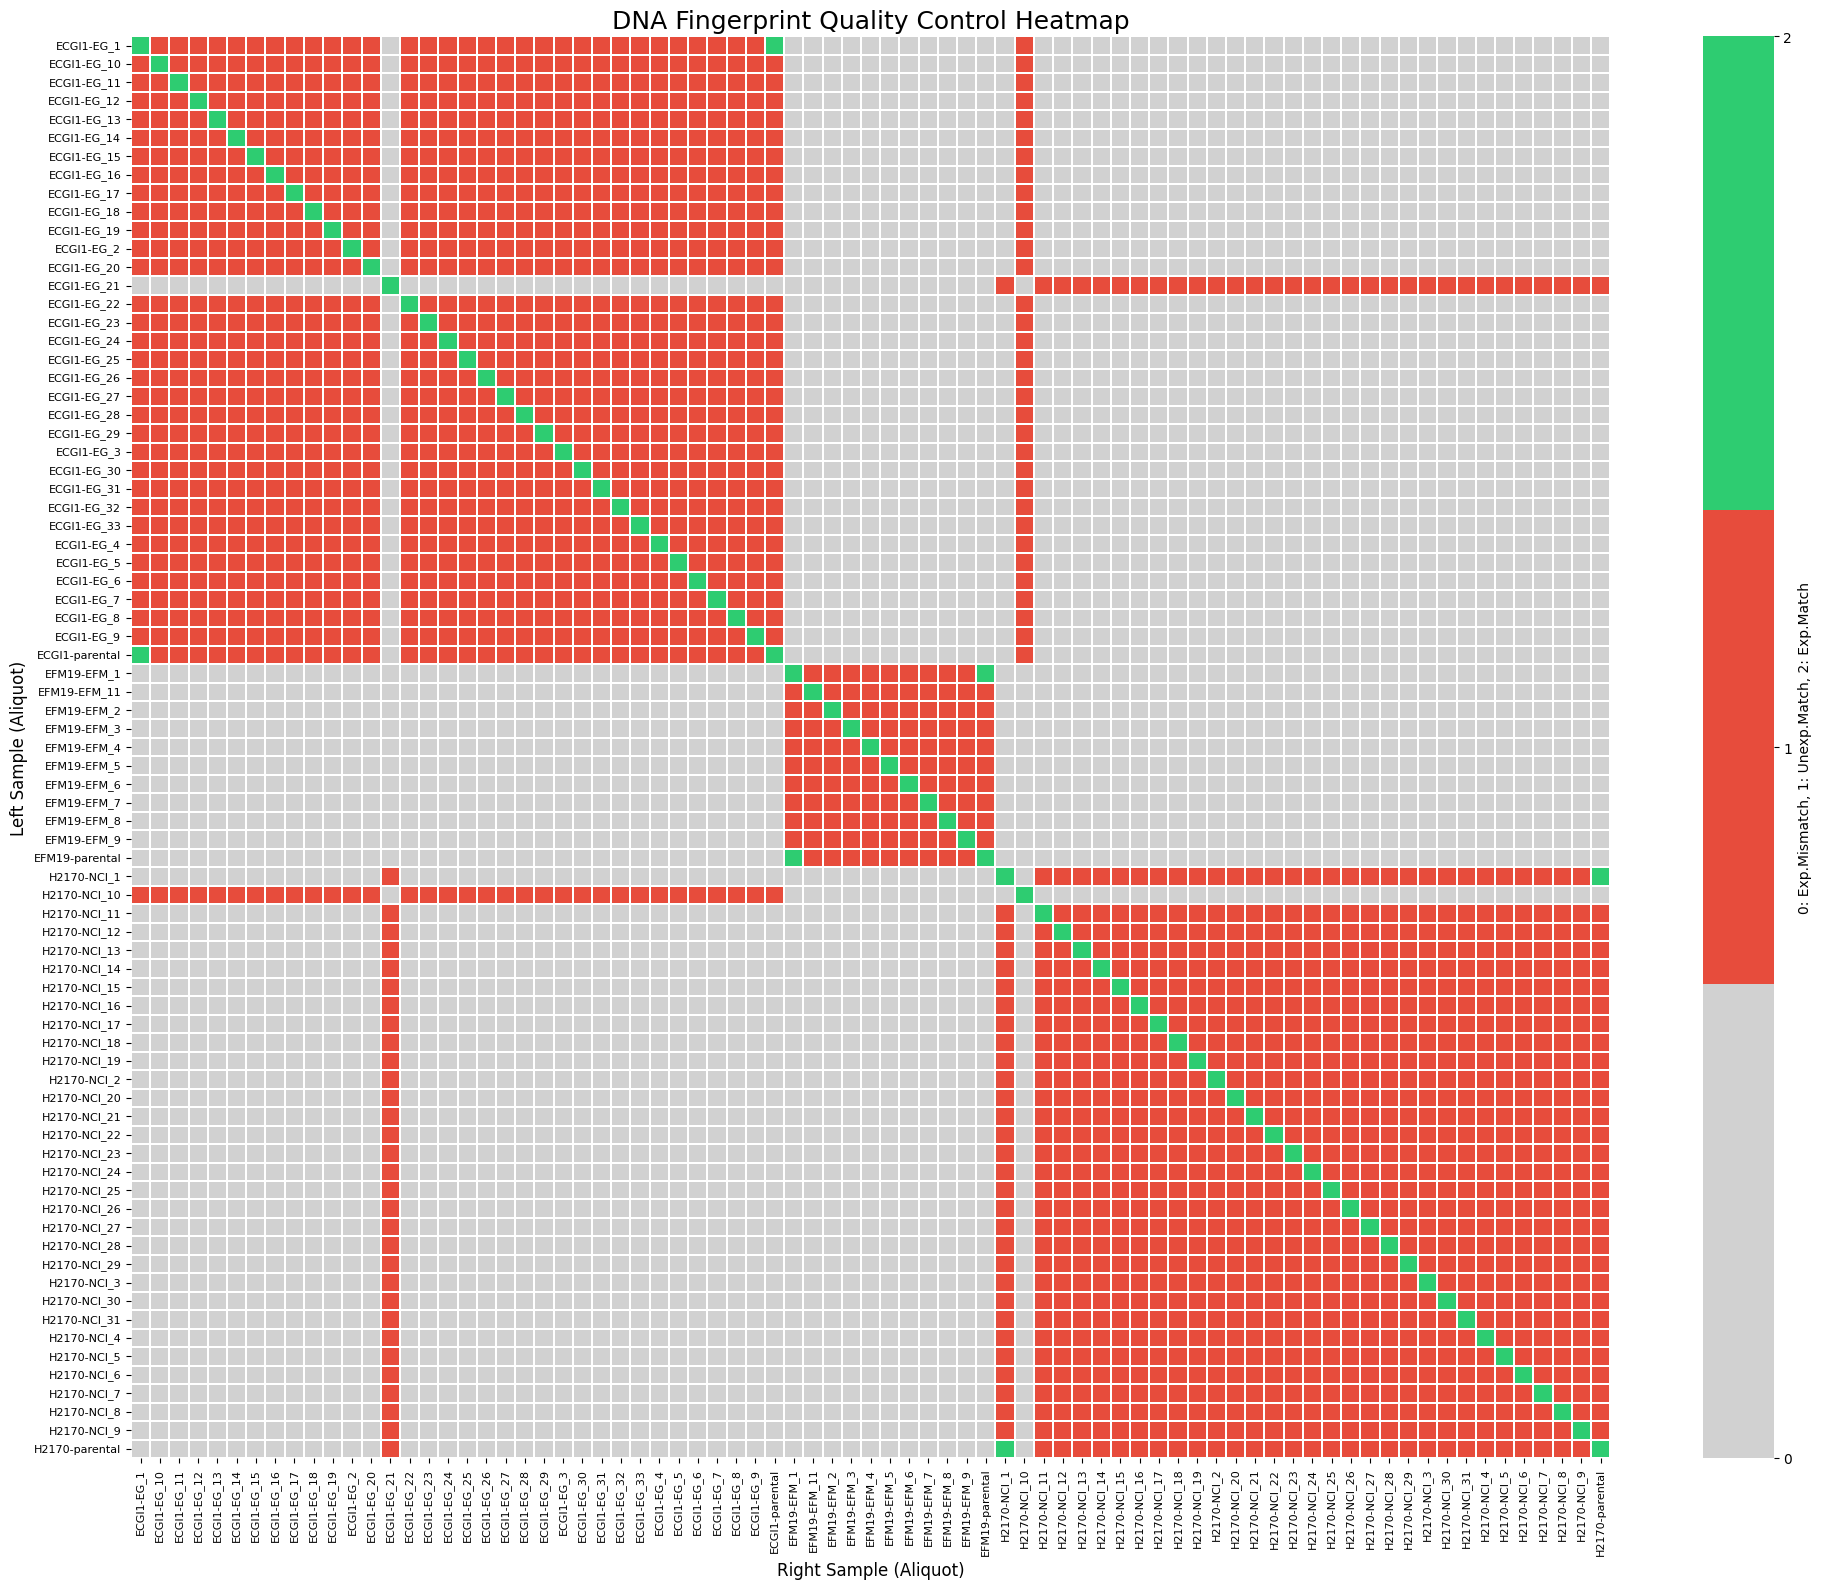

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# 1. 결과값(RESULT)을 숫자로 매핑 (Heatmap 그리기를 위함)
# 중요도나 의미에 따라 숫자를 부여합니다.
result_map = {
    'EXPECTED_MATCH': 2,      # 녹색 계열 (정상)
    'UNEXPECTED_MATCH': 1,    # 빨간색/주황색 계열 (주의: 오염 혹은 라벨 오류 가능성)
    'EXPECTED_MISMATCH': 0    # 무채색/파란색 계열 (정상)
}
df_mapped['RESULT_NUM'] = df_mapped['RESULT'].map(result_map)

# 2. 정렬을 위해 샘플 리스트 생성 (source_barcode 순서대로 정렬)
# 같은 source_barcode를 가진 샘플들이 인접하게 배치됩니다.
df_mapped = df_mapped.sort_values(['left_source_barcode', 'left_sample_id', 
                                   'right_source_barcode', 'right_sample_id'])

# 3. Pivot Table 생성 (행: Left Sample, 열: Right Sample)
pivot_df = df_mapped.pivot_table(
    index=['left_source_barcode', 'left_sample_id'], 
    columns=['right_source_barcode', 'right_sample_id'], 
    values='RESULT_NUM'
)
# 4. 컬러맵 설정 (수정된 부분)
# 0: 회색, 1: 빨간색, 2: 녹색 순서의 컬러맵을 만듭니다.
my_colors = ["#d1d1d1", "#e74c3c", "#2ecc71"]
my_cmap = ListedColormap(my_colors)

# 5. Heatmap 그리기
plt.figure(figsize=(20, 16)) # 샘플이 많으므로 사이즈를 넉넉하게 잡습니다.

sns.heatmap(
    pivot_df, 
    cmap=my_cmap, 
    linewidths=0.1,    # 칸 사이의 간격을 살짝 줘서 구분되게 함
    linecolor='white',
    cbar_kws={
        'ticks': [0, 1, 2], 
        'label': '0: Exp.Mismatch, 1: Unexp.Match, 2: Exp.Match'
    }
)

plt.title('DNA Fingerprint Quality Control Heatmap', fontsize=18)
plt.xlabel('Right Sample (Aliquot)', fontsize=12)
plt.ylabel('Left Sample (Aliquot)', fontsize=12)

# 라벨이 너무 많아 겹칠 경우를 대비해 폰트 조절
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

# Source 

In [16]:
# dna_fingerprint_all = pd.read_csv(f'{base_dir}/all/crosscheck_metrics')
dna_fingerprint_source_DM_path = f'{base_dir}/dna_fingerprint/patient/colo320DM.crosscheck_metrics'
# Read the file, skipping the first 6 lines
dna_fingerprint_DM = pd.read_csv(dna_fingerprint_source_DM_path, sep='\t', skiprows=6)

# Display the extracted data
dna_fingerprint_DM.shape

(4, 19)

In [29]:
dna_fingerprint_DM[['LEFT_SAMPLE','RIGHT_SAMPLE','RESULT','LOD_SCORE']]

,LEFT_SAMPLE,RIGHT_SAMPLE,RESULT,LOD_SCORE
0,BIOCHP-SKKUM-0001-TPX-A01,BIOCHP-SKKUM-0001-TPX-A01,EXPECTED_MATCH,7711.572986
1,BIOCHP-SKKUM-0001-TPX-A01,SKKURT-320DM-0001-TPX-A01,EXPECTED_MATCH,4942.901867
2,SKKURT-320DM-0001-TPX-A01,BIOCHP-SKKUM-0001-TPX-A01,EXPECTED_MATCH,4942.901867
3,SKKURT-320DM-0001-TPX-A01,SKKURT-320DM-0001-TPX-A01,EXPECTED_MATCH,12239.665360


In [17]:
# dna_fingerprint_all = pd.read_csv(f'{base_dir}/all/crosscheck_metrics')
dna_fingerprint_source_HSR_path = f'{base_dir}/dna_fingerprint/patient/colo320HSR.crosscheck_metrics'
# Read the file, skipping the first 6 lines
dna_fingerprint_HSR = pd.read_csv(dna_fingerprint_source_HSR_path, sep='\t', skiprows=6)

# Display the extracted data
dna_fingerprint_HSR.shape

(4, 19)

In [28]:
dna_fingerprint_HSR[['LEFT_SAMPLE','RIGHT_SAMPLE','RESULT','LOD_SCORE']]

,LEFT_SAMPLE,RIGHT_SAMPLE,RESULT,LOD_SCORE
0,SKKURT-320HS-0001-TPX-A01,SKKURT-320HS-0001-TPX-A01,EXPECTED_MATCH,12153.252794
1,SKKURT-320HS-0001-TPX-A01,BIOCHP-SKKUM-0002-TPX-A01,EXPECTED_MATCH,1459.984004
2,BIOCHP-SKKUM-0002-TPX-A01,SKKURT-320HS-0001-TPX-A01,EXPECTED_MATCH,1459.984004
3,BIOCHP-SKKUM-0002-TPX-A01,BIOCHP-SKKUM-0002-TPX-A01,EXPECTED_MATCH,2389.833392


# ClusterCrosscheckMetrics_all

In [7]:
dna_fingerprint_clustered_path = f'{base_dir}/dna_fingerprint/ClusterCrosscheckMetrics_all/clustered.crosscheck_metrics'
# Read the file, skipping the first 6 lines
dna_fingerprint_clustered = pd.read_csv(dna_fingerprint_clustered_path, sep='\t', skiprows=6)

# Display the extracted data
dna_fingerprint_clustered.shape
dna_fingerprint_clustered[['CLUSTER', 'CLUSTER_SIZE','LEFT_SAMPLE','RIGHT_SAMPLE','RESULT']]


,CLUSTER,CLUSTER_SIZE,LEFT_SAMPLE,RIGHT_SAMPLE,RESULT
0,0,34,ECTRES-ECGI1-0001-TPX-A26,ECTRES-ECGI1-0001-TPX-A23,UNEXPECTED_MATCH
1,0,34,ECTRES-ECGI1-0001-TPX-A18,ECTRES-ECGI1-0001-TPX-A31,UNEXPECTED_MATCH
2,0,34,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001-TPX-A11,UNEXPECTED_MATCH
3,0,34,ECTRES-ECGI1-0001-TPX-A08,ECTRES-ECGI1-0001-TPX-A30,UNEXPECTED_MATCH
4,0,34,ECTRES-ECGI1-0001-TPX-A04,ECTRES-ECGI1-0001-TPX-A12,UNEXPECTED_MATCH
...,...,...,...,...,...
2296,34,32,ECTRES-H2170-0001-TPX-A29,ECTRES-H2170-0001-TPX-A30,UNEXPECTED_MATCH
2297,34,32,ECTRES-H2170-0001-TPX-A07,ECTRES-H2170-0001-TPX-A31,UNEXPECTED_MATCH
2298,34,32,ECTRES-H2170-0001-TPX-A19,ECTRES-H2170-0001-TPX-A07,UNEXPECTED_MATCH
2299,34,32,ECTRES-H2170-0001-TPX-A25,ECTRES-H2170-0001-TPX-A02,UNEXPECTED_MATCH


In [8]:
dna_fingerprint_clustered.columns

Index(['CLUSTER', 'CLUSTER_SIZE', 'LEFT_GROUP_VALUE', 'RIGHT_GROUP_VALUE',
       'RESULT', 'DATA_TYPE', 'LOD_SCORE', 'LOD_SCORE_TUMOR_NORMAL',
       'LOD_SCORE_NORMAL_TUMOR', 'LEFT_RUN_BARCODE', 'LEFT_LANE',
       'LEFT_MOLECULAR_BARCODE_SEQUENCE', 'LEFT_LIBRARY', 'LEFT_SAMPLE',
       'LEFT_FILE', 'RIGHT_RUN_BARCODE', 'RIGHT_LANE',
       'RIGHT_MOLECULAR_BARCODE_SEQUENCE', 'RIGHT_LIBRARY', 'RIGHT_SAMPLE',
       'RIGHT_FILE'],
      dtype='object')

In [9]:
dna_fingerprint_clustered

,CLUSTER,CLUSTER_SIZE,LEFT_GROUP_VALUE,RIGHT_GROUP_VALUE,RESULT,DATA_TYPE,LOD_SCORE,LOD_SCORE_TUMOR_NORMAL,LOD_SCORE_NORMAL_TUMOR,LEFT_RUN_BARCODE,...,LEFT_MOLECULAR_BARCODE_SEQUENCE,LEFT_LIBRARY,LEFT_SAMPLE,LEFT_FILE,RIGHT_RUN_BARCODE,RIGHT_LANE,RIGHT_MOLECULAR_BARCODE_SEQUENCE,RIGHT_LIBRARY,RIGHT_SAMPLE,RIGHT_FILE
0,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1900.520687,-4022.743367,-4091.598475,2333VCLT4,...,NaN,ZKDN250033017,ECTRES-ECGI1-0001-TPX-A26,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033014,ECTRES-ECGI1-0001-TPX-A23,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
1,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1873.345550,-4123.781855,-4106.375147,2333VCLT4,...,NaN,ZKDN250033009,ECTRES-ECGI1-0001-TPX-A18,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033022,ECTRES-ECGI1-0001-TPX-A31,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,3769.914958,-5356.511531,-4689.576777,22NJLGLT4,...,NaN,DKDN250022574,ECTRES-ECGI1-0001-TPX-A01,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,232N3WLT3,8,NaN,ZKDN250033002,ECTRES-ECGI1-0001-TPX-A11,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
3,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1639.754980,-3693.394107,-3750.827866,2333VCLT4,...,NaN,ZKDN250032999,ECTRES-ECGI1-0001-TPX-A08,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033021,ECTRES-ECGI1-0001-TPX-A30,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
4,0,34,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1764.135921,-5935.224129,-5948.427434,<MULTIPLE_VALUES>,...,NaN,ZKDN250032995,ECTRES-ECGI1-0001-TPX-A04,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,232N3WLT3,8,NaN,ZKDN250033003,ECTRES-ECGI1-0001-TPX-A12,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2296,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1688.546910,-4224.192959,-4408.547366,237Y7NLT3,...,NaN,DKDN260000047,ECTRES-H2170-0001-TPX-A29,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,237Y7NLT3,4,NaN,DKDN260000048,ECTRES-H2170-0001-TPX-A30,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2297,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1753.841344,-4070.770065,-4312.721250,2333VCLT4,...,NaN,ZKDN250033031,ECTRES-H2170-0001-TPX-A07,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,237Y7NLT3,4,NaN,DKDN260000049,ECTRES-H2170-0001-TPX-A31,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2298,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1640.921371,-4099.020569,-4288.097477,237Y7NLT3,...,NaN,DKDN260000037,ECTRES-H2170-0001-TPX-A19,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,8,NaN,ZKDN250033031,ECTRES-H2170-0001-TPX-A07,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...
2299,34,32,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,UNEXPECTED_MATCH,FILE,1506.423083,-3901.198000,-4056.156947,237Y7NLT3,...,NaN,DKDN260000043,ECTRES-H2170-0001-TPX-A25,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...,2333VCLT4,7,NaN,ZKDN250033026,ECTRES-H2170-0001-TPX-A02,file:///mnt/storage/tmp/nxf.LHADba43NA/ECTRES-...


In [11]:
df_fp=dna_fingerprint[['LEFT_SAMPLE','RIGHT_SAMPLE','RESULT']]

df_fp['LEFT_SAMPLE'] = df_fp['LEFT_SAMPLE'].apply(assign_tag2)
df_fp['RIGHT_SAMPLE'] = df_fp['RIGHT_SAMPLE'].apply(assign_tag2)

NameError: name 'dna_fingerprint' is not defined

In [10]:
matrix = pd.DataFrame(np.nan, index=order2, columns=order2)
for _, row in df_fp.iterrows():
    left = row['LEFT_SAMPLE']
    right = row['RIGHT_SAMPLE']
    if left in order2 and right in order2:
        val = 1 if row['RESULT'] == 'EXPECTED_MATCH' else 0.99
        matrix.loc[left, right] = val
        matrix.loc[right, left] = val  # 대칭 채움

# 자기 자신은 1
for tag in order2:
    matrix.loc[tag, tag] = 1

# 상삼각 마스크
mask_upper = np.tril(np.ones_like(matrix, dtype=bool), k=-1)  # 왼쪽 아래 삼각형만 표시
# mask_upper = np.triu(np.ones_like(matrix, dtype=bool), k=1)

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, mask=~mask_upper, cmap="Reds", annot=True, fmt=".2f", square=True,
            linewidths=0.5, cbar_kws={'label': 'Match Status'}, vmin=0.99, vmax=1.0)

plt.title("CrosscheckFingerprint Match Heatmap (Lower Triangular, 1=Expected, 0.99=Unexpected)")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'order2' is not defined